In [1]:
import matplotlib.pyplot as plt
import numpy as np
import os, glob
import pandas as pd
from pathlib import Path
from collections import namedtuple
import matplotlib.cm as cm
import matplotlib.colors as mcolors

plt.rcParams['text.usetex'] = False

stats = namedtuple('Statistics', ['x', 'entropy', 'gap', 'times'])

In [2]:
def get_col(file, col_name='recovery_rate'):
    df = pd.read_csv(file, usecols=[col_name], header=0, engine="pyarrow")
    y = df[col_name]
    return np.array(y)


def get_data_size(file):
    x = float(Path(file).name.split('=')[1].split('-')[0])
    return x


def get_stats(folders, t, percentage=True, sort=False):    
    assert len(folders) > 0
    
    if sort:
        folders.sort(key = lambda f: float(Path(f).name))
        
    file_stats = stats([], [], [], [])

    missing = 0
    for f in folders:
        x = float(Path(f).name)

        try:
            csv = glob.glob(os.path.join(f, f'entropy_from_t={t}*.csv'))[0]
        except:
            print(f, glob.glob(os.path.join(f, f'entropy_from_t={t}_*.csv')))
            missing += 1
            continue
        
        ent = get_col(csv, col_name='entropy')
        gap = get_col(csv, col_name='spectral_gap')
        
        ts = get_col(csv, col_name='t')
        
        file_stats.x.append(x)
        file_stats.times.append(ts)
        
        file_stats.entropy.append(ent)
        file_stats.gap.append(gap)

    
    print(f'Missing {missing} out of {len(folders)} files.')    
    return file_stats

In [15]:
size = 'small'

t = 1.0

folders = glob.glob(f'../old-experiments/entropy_overtime/lm1b-wrap-{size}/*')
folders.sort(key = lambda f: float(Path(f).name))

curv_stats = get_stats(folders, t)
folders, len(folders)

Missing 0 out of 38 files.


(['../old-experiments/entropy_overtime/lm1b-wrap-small/0.0001',
  '../old-experiments/entropy_overtime/lm1b-wrap-small/0.002575',
  '../old-experiments/entropy_overtime/lm1b-wrap-small/0.00505',
  '../old-experiments/entropy_overtime/lm1b-wrap-small/0.007525',
  '../old-experiments/entropy_overtime/lm1b-wrap-small/0.01',
  '../old-experiments/entropy_overtime/lm1b-wrap-small/0.04',
  '../old-experiments/entropy_overtime/lm1b-wrap-small/0.07',
  '../old-experiments/entropy_overtime/lm1b-wrap-small/0.1',
  '../old-experiments/entropy_overtime/lm1b-wrap-small/0.13',
  '../old-experiments/entropy_overtime/lm1b-wrap-small/0.16',
  '../old-experiments/entropy_overtime/lm1b-wrap-small/0.19',
  '../old-experiments/entropy_overtime/lm1b-wrap-small/0.22',
  '../old-experiments/entropy_overtime/lm1b-wrap-small/0.25',
  '../old-experiments/entropy_overtime/lm1b-wrap-small/0.28',
  '../old-experiments/entropy_overtime/lm1b-wrap-small/0.31',
  '../old-experiments/entropy_overtime/lm1b-wrap-small/0.3

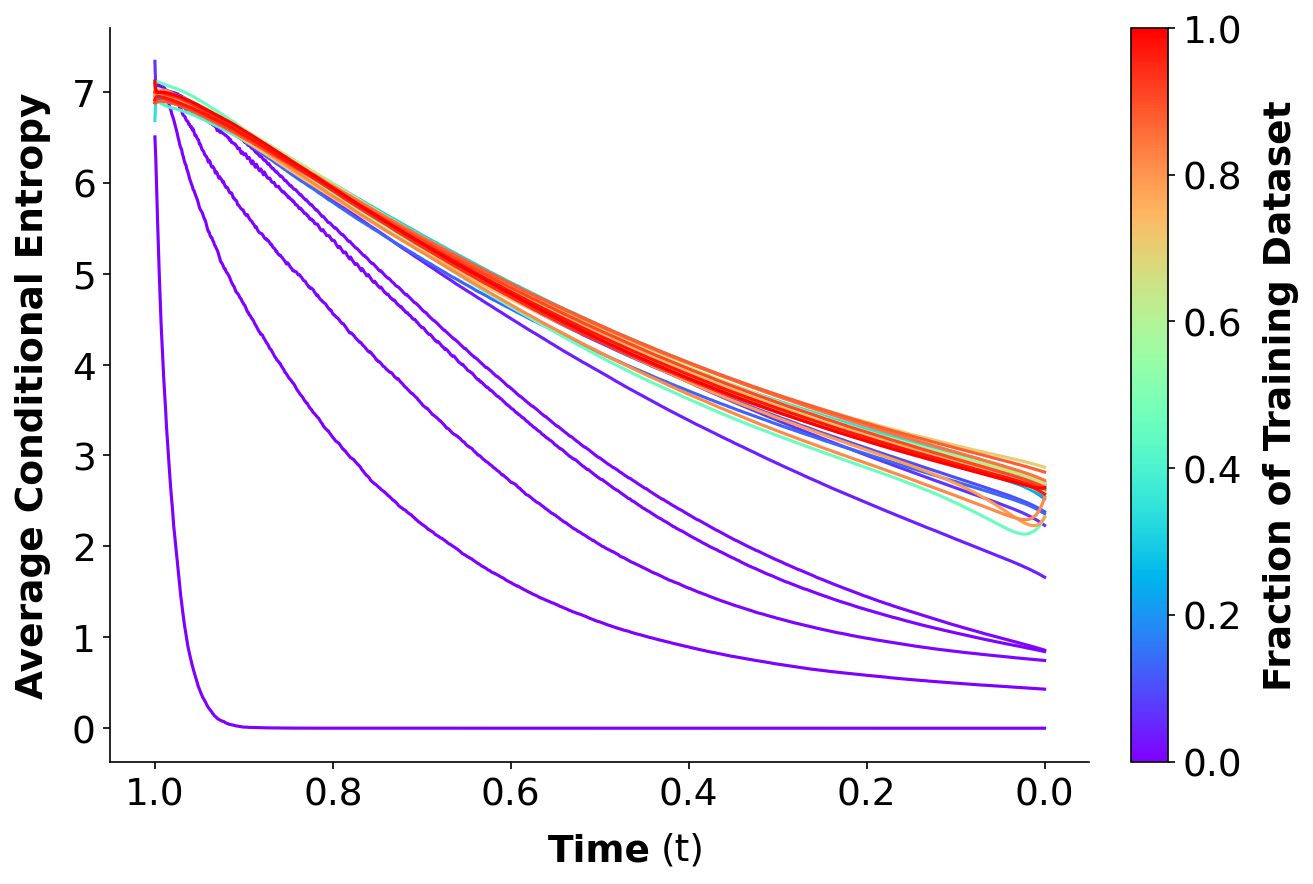

In [16]:
# 1. Setup Figure and Axes explicitly
fig, ax = plt.subplots(figsize=(9, 6), dpi=150)

fontsize = 18

min_fraction = 0.0  
max_fraction = 1.0  

norm = mcolors.Normalize(vmin=min_fraction, vmax=max_fraction)
colormap = plt.get_cmap('rainbow') 

# 2. Plotting Loop
for i, ts in enumerate(curv_stats.times):
    frac = curv_stats.x[i]
    line_color = colormap(norm(frac))
    
    # Note: Use 'ax.errorbar' instead of 'plt.errorbar'
    ax.errorbar(ts, curv_stats.entropy[i], label=f'Fraction: {frac}', color=line_color)

# 3. Create the ScalarMappable
sm = cm.ScalarMappable(cmap=colormap, norm=norm)
sm.set_array([]) 

# 4. Add Colorbar - Explicitly telling it which Axes to steal space from
# The 'ax=ax' argument fixes your error.
cbar = fig.colorbar(sm, ax=ax, pad=0.035)
cbar.set_label('Fraction of Training Dataset', fontsize=fontsize, labelpad=10, weight='bold')
cbar.ax.tick_params(labelsize=fontsize)

# 5. Final Formatting (applied to the specific axes 'ax')
ax.set_ylabel('Average Conditional Entropy', fontsize=fontsize, labelpad=10, weight='bold')

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

ax.set_xlabel('Time', fontsize=fontsize, labelpad=10, weight='bold')

ax.tick_params(axis='both', which='major', labelsize=fontsize)

ax.text(0.585, -0.095, '(t)', transform=ax.transAxes, 
        fontsize=fontsize, weight='normal', ha='center', va='top')

#ax.grid(True, which='major', linestyle=':')
ax.invert_xaxis()
plt.tight_layout()
plt.show()

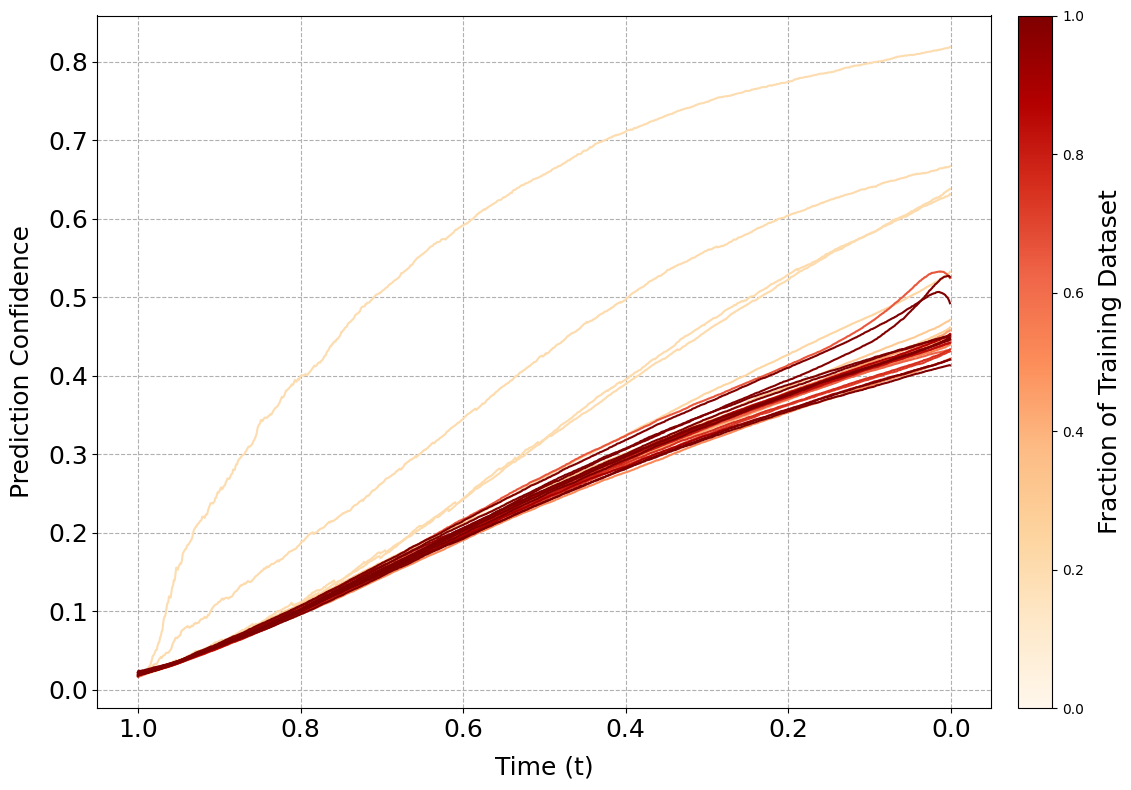

In [113]:
# 1. Setup Figure and Axes explicitly
fig, ax = plt.subplots(figsize=(12, 8))

min_fraction = 0.0  
max_fraction = 1.0  

norm = mcolors.Normalize(vmin=min_fraction, vmax=max_fraction)
colormap = plt.get_cmap('OrRd') 

# 2. Plotting Loop
for i, ts in enumerate(curv_stats.times):
    frac = curv_stats.x[i]
    line_color = colormap(norm(frac) + 0.2)
    
    # Note: Use 'ax.errorbar' instead of 'plt.errorbar'
    ax.errorbar(ts, curv_stats.gap[i], label=f'Fraction: {frac}', color=line_color)

# 3. Create the ScalarMappable
sm = cm.ScalarMappable(cmap=colormap, norm=norm)
sm.set_array([]) 

# 4. Add Colorbar - Explicitly telling it which Axes to steal space from
# The 'ax=ax' argument fixes your error.
cbar = fig.colorbar(sm, ax=ax, pad=0.025)
cbar.set_label('Fraction of Training Dataset', fontsize=18, labelpad=10)

# 5. Final Formatting (applied to the specific axes 'ax')
ax.set_ylabel('Prediction Confidence', fontsize=18, labelpad=10)
ax.set_xlabel('Time (t)', fontsize=18, labelpad=10)
ax.tick_params(axis='both', which='major', labelsize=18)
ax.grid(True, linestyle='--')
ax.invert_xaxis()
plt.tight_layout()
plt.show()